In [1]:
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import math
import numpy as np
from shapely.geometry import Point
import random
import datetime

In [2]:
BASE_OUTPUT_DIR = "data/"
GTFS_DIR = "generate_data/gtfs/"

In [3]:
def osmnx_routing_graph(addr='Manhattan, New York City, New York, USA', 
                        buffer_dist=500):
    """
    Uses OSMNX to get OSM routing graph for a city. Returns the routing graph (networkx)
    as well as the nodes and edges as pandas DataFrames. buffer_dist will expand the
    OSM network by buffer_dist (meters) in all directions.
    
    :param addr: str
    :param buffer_dist: int
    :return: networkx.MultiDiGraph, pandas.DataFrame, pandas.DataFrame
    """
    # get the OSM graph
    G = ox.graph_from_place(addr,
                            network_type='drive',
                            simplify=True,
                            truncate_by_edge=True,
                            retain_all=False,
                            buffer_dist=buffer_dist)
    G = ox.utils_graph.get_largest_component(G, strongly=True)

    # add edge speeds
    G = ox.speed.add_edge_speeds(G, fallback=40.2, precision=6)

    # add edge travel time
    G = ox.speed.add_edge_travel_times(G, precision=6)
    for n1, n2, k in G.edges(keys=True):
        G[n1][n2][k]['travel_time'] = math.ceil(G[n1][n2][k]['travel_time'])


    nodes, edges = ox.utils_graph.graph_to_gdfs(G)

    # format nodes
    nodes['osmid'] = nodes.index
    nodes.index = range(len(nodes))
    nodes['node_id'] = nodes.index
    nodes['lon'] = nodes['x']
    nodes['lat'] = nodes['y']
    nodes = nodes[['node_id', 'osmid', 'lat', 'lon']]
    nodes['node_id'] = nodes['node_id'].astype(int)
    nodes['osmid'] = nodes['osmid'].astype(int)
    nodes['lat'] = nodes['lat'].astype(float)
    nodes['lon'] = nodes['lon'].astype(float)

    # format edges
    edges = edges.reset_index()
    edges['source_osmid'] = edges['u']
    edges['target_osmid'] = edges['v']
    edges['source_node'] = edges['source_osmid'].apply(lambda x: nodes.loc[nodes['osmid']==x, 'node_id'].values[0])
    edges['target_node'] = edges['target_osmid'].apply(lambda x: nodes.loc[nodes['osmid']==x, 'node_id'].values[0])
    edges = edges.sort_values(by=['travel_time'])
    edges = edges.drop_duplicates(subset=['source_node', 'target_node'])
    edges = edges[['source_osmid', 'target_osmid', 'source_node', 'target_node', 'travel_time']]
    edges['source_osmid'] = edges['source_osmid'].astype(int)
    edges['target_osmid'] = edges['target_osmid'].astype(int)
    edges['source_node'] = edges['source_node'].astype(int)
    edges['target_node'] = edges['target_node'].astype(int)
    edges['travel_time'] = edges['travel_time'].astype(int)
    # format edge types
    print(f"Number of nodes: {len(nodes)}, number of edges: {len(edges)}")
    return G, nodes, edges



Number of nodes: 5018, number of edges: 10840


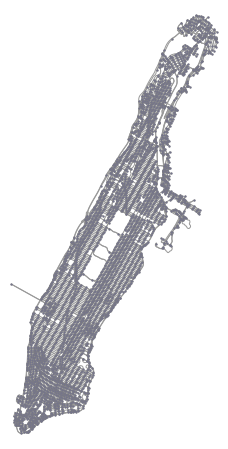

(<Figure size 576x576 with 1 Axes>, <AxesSubplot:>)

In [4]:
G, nodes, edges = osmnx_routing_graph(addr='Manhattan, New York City, New York, USA', 
                        buffer_dist=500)
ox.plot_graph(G, node_color='b', node_size=2, node_edgecolor='grey', bgcolor = 'white')

In [27]:
total_length = 0
total_time = 0
speeds = []
for n1, n2, k in G.edges(keys=True):
    total_length+=G[n1][n2][k]['length']
    total_time+=G[n1][n2][k]['travel_time']
    speed=G[n1][n2][k]['speed_kph']
    if speed not in speeds:
        speeds.append(speed)

total_length/total_time

10.785019680318051

In [21]:
def generateMap(G,nodes,edges):
    OUTPUT_DIR = BASE_OUTPUT_DIR+"map/"

    # shortest_path_length=dict(nx.all_pairs_dijkstra_path_length(G, weight='travel_time'))
    # with open(OUTPUT_DIR+"times.csv", 'a+') as output_file:
    #     for origin in range(len(nodes)):
    #         values = []
    #         origin_osmid = nodes.loc[nodes['node_id']==origin,'osmid'].iloc[0]
    #         for destination in range(len(nodes)):
    #             destination_osmid = nodes.loc[nodes['node_id']==destination,'osmid'].iloc[0]
    #             values.append(shortest_path_length[origin_osmid][destination_osmid])
    #         output_file.write(",".join([str(i) for i in values])+"\n")

    with open(OUTPUT_DIR+"pred.csv", 'a+') as pred_file:
        with open(OUTPUT_DIR+"times.csv", 'a+') as times_file:
            for origin in range(len(nodes)):
                travel_times = []
                predecessors = []
                origin_osmid = nodes.loc[nodes['node_id']==origin,'osmid'].iloc[0]
                pred,travel_time=nx.dijkstra_predecessor_and_distance(G, origin_osmid,weight='travel_time')
                for destination in range(len(nodes)):
                    destination_osmid = nodes.loc[nodes['node_id']==destination,'osmid'].iloc[0]
                    travel_times.append(travel_time[destination_osmid])
                    if destination == origin:
                        predecessor = 0
                    else:
                        predecessor = nodes.loc[nodes['osmid']==pred[destination_osmid][0],'node_id'].iloc[0]+1
                    predecessors.append(predecessor)
                pred_file.write(",".join([str(i) for i in predecessors])+"\n")
                times_file.write(",".join([str(i) for i in travel_times])+"\n")

    nodes['node_id'] = nodes['node_id'].apply(lambda x: x + 1)
    nodes = nodes[['node_id', 'lat', 'lon']]
    nodes.to_csv(OUTPUT_DIR+'nodes.csv', header=False, index=False)

    edges['source_node'] = edges['source_node'].apply(lambda x: x + 1)
    edges['target_node'] = edges['target_node'].apply(lambda x: x + 1)
    edges['travel_time'] = edges['travel_time'].apply(lambda x: math.ceil(x))
    edges = edges[['source_node', 'target_node', 'travel_time']]
    edges.to_csv(OUTPUT_DIR+'edges.csv', header=False, index=False)

In [6]:
def generateRequests(G,nodes,address,filename,start,end):

    DROPOFF_LAT = 'dropoff_latitude'
    DROPOFF_LONG = 'dropoff_longitude'
    PICKUP_LAT = 'pickup_latitude'
    PICKUP_LONG = 'pickup_longitude'
    PICKUP_TIME = 'tpep_pickup_datetime'
    TRIP_DISTANCE = 'trip_distance'
    ORIGIN = 'origin'
    DEST = 'dest'

    # def getData(filename):
    #     return pd.read_csv(filename,parse_dates=True, usecols=[PICKUP_TIME, PICKUP_LONG, PICKUP_LAT, DROPOFF_LONG, DROPOFF_LAT, TRIP_DISTANCE]).sort_values(by = [PICKUP_TIME])

    city = ox.geocode_to_gdf(address)
    geom = city.loc[0, 'geometry']

    data = pd.read_csv(filename,parse_dates=True, usecols=[PICKUP_TIME, PICKUP_LONG, PICKUP_LAT, DROPOFF_LONG, DROPOFF_LAT, TRIP_DISTANCE]).sort_values(by = [PICKUP_TIME])
    data = data.loc[(data[PICKUP_TIME] >= start) & 
                                (data[PICKUP_TIME] < end)]
    count = data.shape[0]
    data.insert(6,ORIGIN,np.zeros(count))
    data.insert(7,DEST,np.zeros(count))

    print("Trips in selected time interval: {0}".format(count))

    selected_trips = []
    num_processed = 0
    for index, row in data.iterrows():
            print(num_processed, end='\r')
            num_processed+=1
            cord1 = (row[PICKUP_LONG],row[PICKUP_LAT])
            cord2 = (row[DROPOFF_LONG], row[DROPOFF_LAT])
            fit1 = geom.intersects(Point(cord1))
            fit2 = geom.intersects(Point(cord2))
            if fit1 and fit2:
                ori = ox.distance.nearest_nodes(G, row[PICKUP_LONG],row[PICKUP_LAT])
                des = ox.distance.nearest_nodes(G, row[DROPOFF_LONG], row[DROPOFF_LAT])
                origin = None
                destination = None
                if type(ori) == list:
                    origin = ori[0]
                else:
                    origin = ori
                if type(des) == list:    
                    destination = des[0]
                else:  
                    destination = des
                    
                data.at[index,ORIGIN] = nodes.loc[nodes['osmid']==origin,'node_id'].iloc[0]+1
                data.at[index,DEST] = nodes.loc[nodes['osmid']==destination,'node_id'].iloc[0]+1
                # if origin != destination and (origin in shortest_path_length and destination in shortest_path_length[origin]):
                selected_trips.append(index)

    print("Trips after filtering: {0}".format(len(selected_trips)))
    data.loc[selected_trips].to_csv(BASE_OUTPUT_DIR+"requests/requests.csv")
#  getData('yellow_tripdata_2015-01.csv')



In [11]:
generateRequests(G,nodes,'Manhattan, New York City, New York, USA','yellow_tripdata_2015-01.csv',"2015-01-01 00:00:00","2015-01-02 00:00:00")

Trips in selected time interval: 382014


In [9]:
generateMap(G,nodes,edges)

In [22]:
def generateVehicles(nodes,vehicle_num,vehicle_capacity):
    vehicles = pd.DataFrame()
    # randomly generate starting points 
    start_node = random.choices(nodes.index.to_list(), k=vehicle_num)
    for n in start_node:
        vehicles = vehicles.append(nodes.iloc[n], ignore_index=True)

    vehicles.columns = ['node id', 'osmid', 'node lat', 'node lon']
    vehicles['vehicle id'] = list(range(1, vehicle_num+1))
    vehicles['start time'] = datetime.time(0,0,0)
    vehicles['capacity'] = vehicle_capacity

    # formatting
    vehicles['node id'] = vehicles['node id'].astype('int')
    vehicles = vehicles[['vehicle id', 'node id', 'node lat', 'node lon', 'start time', 'capacity']]
    vehicles.to_csv(BASE_OUTPUT_DIR+'/vehicles/vehicles.csv', index = False, header = False)

In [23]:
generateVehicles(nodes,10000,4)

In [9]:
frequencies = {"M1":3,"M2":4,"M3":4,"M5":4,"M4":4,"M7":4,"M8":6,
             "M9":6,"M10":3,"M11":4,"M12":2,"M20":2,"M21":2,"M31":4,
             "M42":6,"M50":3,"M55":3,"M57":6,"M66":3,"M72":3,"M96":12,"M98":3,"M101":6,"M104":6}

trips = pd.read_csv(GTFS_DIR+"trips.txt") 
stop_times = pd.read_csv(GTFS_DIR+"stop_times.txt")
stops = pd.read_csv(GTFS_DIR+"stops.txt")

route_trips = {}
for route in frequencies:
    route_trips[route] = []
    for direction_id in [0,1]:
        trips_in_route = trips[(trips["route_id"]==route) & (trips["direction_id"]==direction_id)]
        shape_id = trips_in_route['shape_id'].value_counts().idxmax()
        trip_id = trips_in_route[trips_in_route['shape_id'] == shape_id].iloc[0]['trip_id']
        route_trips[route].append(trip_id)

routes = {}
complete_routes = {}
for route in route_trips:
    paths = {}
    for trip_id in route_trips[route]:
        paths[trip_id] = []
        route_stops = stop_times[stop_times['trip_id']==trip_id].sort_values(by = ['stop_sequence'])
        for _,row in route_stops.iterrows():
            stop = stops[stops['stop_id']==row['stop_id']]
            node = ox.distance.nearest_nodes(G, stop['stop_lon'],stop['stop_lat'])[0]
            paths[trip_id].append(node)
    trip_id1 = route_trips[route][0]
    trip_id2 = route_trips[route][1]
    routes[route] = paths[trip_id1]
    if paths[trip_id1][-1] == paths[trip_id2][0]:
        routes[route] = routes[route] + paths[trip_id2][1:]
    else:
        routes[route] = routes[route] + paths[trip_id2]
        
    if paths[trip_id1][0] != paths[trip_id2][-1]:
        routes[route].append(paths[trip_id1][0])

    complete_routes[route] = []
    for path in paths:
        stops_seq = paths[path]
        complete_routes[route].append([stops_seq[0]])
        num_stops = len(stops_seq)
        for i in range(1,num_stops):
            origin = stops_seq[i-1]
            des = stops_seq[i]
            node_seq=nx.shortest_path(G, origin,des,weight='travel_time')
            complete_routes[route][-1] = complete_routes[route][-1] +node_seq[1:]

In [62]:
OUTPUT_DIR = BASE_OUTPUT_DIR+"bus/"
for route in routes:
    freq = frequencies[route]
    filename = "{0}_{1}.csv".format(route,freq)
    with open(OUTPUT_DIR+filename,"a+") as file:
        for node in routes[route]:
            node_id = nodes.loc[nodes['osmid']==node,'node_id'].iloc[0]
            file.write(str(node_id)+"\n")

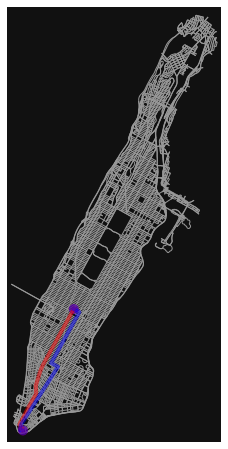

In [58]:
rc = ['r', 'b']
fig, ax = ox.plot_graph_routes(G, complete_routes["M55"], route_colors=rc, route_linewidth=6, node_size=0)